In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data Demostartion

In [2]:
df = pd.read_csv('Data/Raw_data/IM2606_20260515.csv', usecols=[0] + list(range(5, 25)))
df

,timestamp,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,ask4,...,bidSize1,bidSize2,bidSize3,bidSize4,bidSize5,askSize1,askSize2,askSize3,askSize4,askSize5
0,20260515 09:29:00.113806,8710.0,8709.8,8705.8,8705.0,8704.8,8711.0,8711.8,8712.2,8712.4,...,5.0,3.0,2.0,5.0,1.0,1.0,8.0,5.0,2.0,1.0
1,20260515 09:30:00.519956,8710.0,8709.8,8705.8,8705.0,8704.8,8710.2,8717.0,8717.6,8717.8,...,7.0,7.0,2.0,5.0,1.0,1.0,2.0,1.0,7.0,4.0
2,20260515 09:30:01.021552,8711.2,8711.0,8710.2,8710.0,8709.8,8716.4,8718.0,8718.6,8718.8,...,1.0,1.0,23.0,21.0,9.0,11.0,3.0,2.0,1.0,1.0
3,20260515 09:30:01.519457,8711.6,8711.4,8711.2,8711.0,8710.4,8713.2,8714.8,8715.0,8715.2,...,1.0,30.0,3.0,5.0,37.0,1.0,1.0,1.0,1.0,1.0
4,20260515 09:30:02.018199,8716.4,8714.6,8713.6,8713.4,8713.2,8716.6,8718.0,8718.6,8718.8,...,1.0,1.0,1.0,4.0,8.0,1.0,8.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28728,20260515 14:59:58.059378,8582.2,8580.4,8580.2,8580.0,8579.6,8582.6,8587.2,8588.0,8588.8,...,3.0,1.0,8.0,3.0,2.0,1.0,5.0,10.0,1.0,3.0
28729,20260515 14:59:58.562878,8582.6,8581.6,8580.4,8580.2,8580.0,8585.0,8588.0,8588.8,8589.0,...,1.0,10.0,1.0,8.0,3.0,2.0,10.0,1.0,3.0,1.0
28730,20260515 14:59:59.059372,8581.6,8580.4,8580.2,8580.0,8579.6,8582.8,8585.0,8588.0,8588.8,...,8.0,1.0,8.0,3.0,2.0,5.0,1.0,10.0,1.0,3.0
28731,20260515 14:59:59.561837,8581.8,8581.6,8580.4,8580.2,8580.0,8582.8,8585.0,8588.0,8588.8,...,1.0,9.0,1.0,8.0,3.0,1.0,1.0,10.0,1.0,3.0


In [3]:
df['MidPrice'] = (df['bid1'] + df['ask1']) / 2
df['MidPrice']


0        8710.5
1        8710.1
2        8713.8
3        8712.4
4        8716.5
          ...  
28728    8582.4
28729    8583.8
28730    8582.2
28731    8582.3
28732    8582.1
Name: MidPrice, Length: 28733, dtype: float64

In [4]:
def price_micro(df, level: int):
    price_cols = [f'bid{level}', f'ask{level}']
    size_cols = [f'bidSize{level}', f'askSize{level}']   
    df[f'price_micro_{level}'] = (df[price_cols[0]] * df[size_cols[1]] + df[price_cols[1]] * df[size_cols[0]]) / (df[size_cols[0]] + df[size_cols[1]])
    return None

In [5]:
for i in range(1,6):
    price_micro(df, level = i)
df

,timestamp,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,ask4,...,askSize2,askSize3,askSize4,askSize5,MidPrice,price_micro_1,price_micro_2,price_micro_3,price_micro_4,price_micro_5
0,20260515 09:29:00.113806,8710.0,8709.8,8705.8,8705.0,8704.8,8711.0,8711.8,8712.2,8712.4,...,8.0,5.0,2.0,1.0,8710.5,8710.833333,8710.345455,8707.628571,8710.285714,8708.900000
1,20260515 09:30:00.519956,8710.0,8709.8,8705.8,8705.0,8704.8,8710.2,8717.0,8717.6,8717.8,...,2.0,1.0,7.0,4.0,8710.1,8710.175000,8715.400000,8713.666667,8710.333333,8707.440000
2,20260515 09:30:01.021552,8711.2,8711.0,8710.2,8710.0,8709.8,8716.4,8718.0,8718.6,8718.8,...,3.0,2.0,1.0,1.0,8713.8,8711.633333,8712.750000,8717.928000,8718.400000,8718.080000
3,20260515 09:30:01.519457,8711.6,8711.4,8711.2,8711.0,8710.4,8713.2,8714.8,8715.0,8715.2,...,1.0,1.0,1.0,1.0,8712.4,8712.400000,8714.690323,8714.050000,8714.500000,8715.463158
4,20260515 09:30:02.018199,8716.4,8714.6,8713.6,8713.4,8713.2,8716.6,8718.0,8718.6,8718.8,...,8.0,2.0,1.0,1.0,8716.5,8716.500000,8714.977778,8715.266667,8717.720000,8718.355556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28728,20260515 14:59:58.059378,8582.2,8580.4,8580.2,8580.0,8579.6,8582.6,8587.2,8588.0,8588.8,...,5.0,10.0,1.0,3.0,8582.4,8582.500000,8581.533333,8583.666667,8586.600000,8583.360000
28729,20260515 14:59:58.562878,8582.6,8581.6,8580.4,8580.2,8580.0,8585.0,8588.0,8588.8,8589.0,...,10.0,1.0,3.0,1.0,8583.8,8583.400000,8584.800000,8584.600000,8586.600000,8587.050000
28730,20260515 14:59:59.059372,8581.6,8580.4,8580.2,8580.0,8579.6,8582.8,8585.0,8588.0,8588.8,...,1.0,10.0,1.0,3.0,8582.2,8582.338462,8582.700000,8583.666667,8586.600000,8583.360000
28731,20260515 14:59:59.561837,8581.8,8581.6,8580.4,8580.2,8580.0,8582.8,8585.0,8588.0,8588.8,...,1.0,10.0,1.0,3.0,8582.3,8582.300000,8584.660000,8581.090909,8587.844444,8584.500000


In [6]:
df_selected = pd.concat([df.iloc[:, [0]], df.iloc[:, -6:]], axis=1)
df_selected['price_move'] = (df_selected['MidPrice'].shift(-10) - df_selected['MidPrice'])
df_selected['price_move_pctg'] = df_selected['price_move'] / df_selected['MidPrice']
df_selected

,timestamp,MidPrice,price_micro_1,price_micro_2,price_micro_3,price_micro_4,price_micro_5,price_move,price_move_pctg
0,20260515 09:29:00.113806,8710.5,8710.833333,8710.345455,8707.628571,8710.285714,8708.900000,13.2,0.001515
1,20260515 09:30:00.519956,8710.1,8710.175000,8715.400000,8713.666667,8710.333333,8707.440000,13.9,0.001596
2,20260515 09:30:01.021552,8713.8,8711.633333,8712.750000,8717.928000,8718.400000,8718.080000,12.8,0.001469
3,20260515 09:30:01.519457,8712.4,8712.400000,8714.690323,8714.050000,8714.500000,8715.463158,12.7,0.001458
4,20260515 09:30:02.018199,8716.5,8716.500000,8714.977778,8715.266667,8717.720000,8718.355556,10.7,0.001228
...,...,...,...,...,...,...,...,...,...
28728,20260515 14:59:58.059378,8582.4,8582.500000,8581.533333,8583.666667,8586.600000,8583.360000,NaN,NaN
28729,20260515 14:59:58.562878,8583.8,8583.400000,8584.800000,8584.600000,8586.600000,8587.050000,NaN,NaN
28730,20260515 14:59:59.059372,8582.2,8582.338462,8582.700000,8583.666667,8586.600000,8583.360000,NaN,NaN
28731,20260515 14:59:59.561837,8582.3,8582.300000,8584.660000,8581.090909,8587.844444,8584.500000,NaN,NaN


upper bond: 0.01000000%, lower bond: -0.01000000%


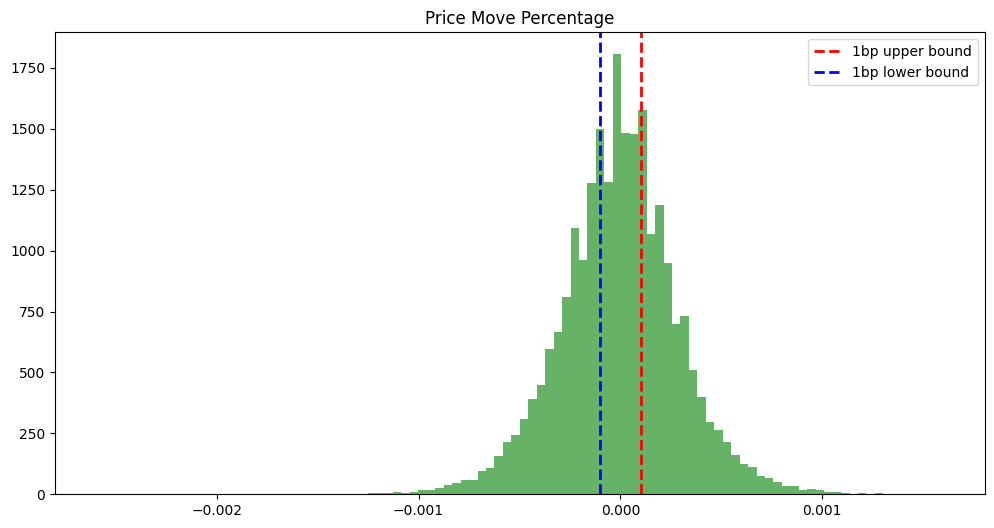

In [ ]:
# Calculate percentiles
percentile_50 = np.nanpercentile(df_selected['price_move_pctg'], 50)
p_upper = percentile_50 + 0.0001
p_lower = percentile_50 - 0.0001
print(f"upper bond: {p_upper*100:0.8f}%, lower bond: {p_lower*100:0.8f}%")
plt.figure(figsize=(12, 6))
plt.hist(df_selected['price_move_pctg'], bins=100, density=True, alpha=0.6, color='g')
plt.axvline(x=p_upper, color='r', linestyle='--', linewidth=2, label=f'1bp upper bound')
plt.axvline(x=p_lower, color='b', linestyle='--', linewidth=2, label=f'1bp lower bound')
plt.title('Price Move Percentage')
plt.legend()
plt.show()

In [25]:
def move_label(x, alpha = 0.0001):
    if x > alpha:
        return 1
    elif x < -alpha:
        return -1
    else:
        return 0

In [26]:
alpha = 0.000035
df_selected['price_move_label'] = df_selected['price_move_pctg'].apply(lambda x: move_label(x, alpha))
df_selected['price_move_label'].value_counts(normalize=True)

price_move_label
-1    0.441563
 1    0.433172
 0    0.125265
Name: proportion, dtype: float64

In [11]:
df_selected

,timestamp,MidPrice,price_micro_1,price_micro_2,price_micro_3,price_micro_4,price_micro_5,price_move,price_move_pctg,price_move_label
0,20260515 09:29:00.113806,8710.5,8710.833333,8710.345455,8707.628571,8710.285714,8708.900000,13.2,0.001515,1
1,20260515 09:30:00.519956,8710.1,8710.175000,8715.400000,8713.666667,8710.333333,8707.440000,13.9,0.001596,1
2,20260515 09:30:01.021552,8713.8,8711.633333,8712.750000,8717.928000,8718.400000,8718.080000,12.8,0.001469,1
3,20260515 09:30:01.519457,8712.4,8712.400000,8714.690323,8714.050000,8714.500000,8715.463158,12.7,0.001458,1
4,20260515 09:30:02.018199,8716.5,8716.500000,8714.977778,8715.266667,8717.720000,8718.355556,10.7,0.001228,1
...,...,...,...,...,...,...,...,...,...,...
28718,20260515 14:59:53.054570,8579.7,8579.945455,8580.627586,8580.300000,8581.100000,8579.150000,2.7,0.000315,1
28719,20260515 14:59:53.555046,8580.9,8581.133333,8581.200000,8581.861538,8583.217391,8581.300000,2.9,0.000338,1
28720,20260515 14:59:54.054941,8582.3,8582.200000,8582.200000,8583.050000,8581.666667,8583.333333,-0.1,-0.000012,0
28721,20260515 14:59:54.555299,8583.3,8583.300000,8583.133333,8583.100000,8583.100000,8583.300000,-1.0,-0.000117,-1


## CNN Structure

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F